In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.collections import LineCollection
import seaborn as sns
from time import sleep
import plotly.express as px
import pandas as pd
from datetime import datetime, timedelta

import fastf1.plotting
import fastf1.livetiming
from fastf1.ergast import Ergast
fastf1.plotting.setup_mpl(mpl_timedelta_support=True, misc_mpl_mods=False)

c:\Users\lmfab\OneDrive\Área de Trabalho\Programas\F1\.venv\Lib\site-packages\fastf1\plotting\_plotting.py:90: FutureWarning: FastF1 will no longer silently modify the default Matplotlib colors in the future.
To remove this warning, explicitly set `color_scheme=None` or `color_scheme='fastf1'` when calling `.setup_mpl()`.
  warnings.warn(


In [2]:
year = 2024
location = "Abu Dhabi"
session = 5

session = fastf1.get_session(year, location, session)
session.load(laps=True, telemetry=True, weather=False, messages=False, livedata=None)

req         WARNING 	DEFAULT CACHE ENABLED! (164.74 MB) C:\Users\lmfab\AppData\Local\Temp\fastf1


core           INFO 	Loading data for Abu Dhabi Grand Prix - Race [v3.4.4]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
core           INFO 	Finished loading data for 20 drivers: ['4', '55', '16', '44', '63', '1', '10', '27', '14', '81', '23', '22', '24', '18', '61', '20', '30', '77', '43', '11']


In [3]:
# session.laps[session.laps["Drisai"] == "SAI"].get_telemetry()
session.car_data["55"]

,Date,RPM,Speed,nGear,Throttle,Brake,DRS,Source,Time,SessionTime
0,2024-12-08 12:06:49.420,0,0,0,0,False,0,NaN,0 days 00:00:02.203000,0 days 00:00:02.203000
1,2024-12-08 12:06:49.740,0,0,0,0,False,0,NaN,0 days 00:00:02.523000,0 days 00:00:02.523000
2,2024-12-08 12:06:49.900,0,0,0,0,False,0,NaN,0 days 00:00:02.683000,0 days 00:00:02.683000
3,2024-12-08 12:06:50.299,0,0,0,0,False,0,NaN,0 days 00:00:03.082000,0 days 00:00:03.082000
4,2024-12-08 12:06:50.499,0,0,0,0,False,0,NaN,0 days 00:00:03.282000,0 days 00:00:03.282000
...,...,...,...,...,...,...,...,...,...,...
33614,2024-12-08 14:35:29.328,0,0,0,104,True,0,car,0 days 02:28:42.111000,0 days 02:28:42.111000
33615,2024-12-08 14:35:29.568,0,0,0,104,True,0,car,0 days 02:28:42.351000,0 days 02:28:42.351000
33616,2024-12-08 14:35:29.808,0,0,0,104,True,0,car,0 days 02:28:42.591000,0 days 02:28:42.591000
33617,2024-12-08 14:35:30.048,0,0,0,104,True,0,car,0 days 02:28:42.831000,0 days 02:28:42.831000


In [4]:
circuit_info = session.get_circuit_info()

core        WARNING 	Failed to preserve data type for column 'X' while merging telemetry.
core        WARNING 	Failed to preserve data type for column 'Y' while merging telemetry.
core        WARNING 	Failed to preserve data type for column 'Z' while merging telemetry.


req            INFO 	Using cached data for driver_info


'SAINZ: 1:27:765000'

'NORRIS: 1:27:765000'

'MAG: 1:25:637000'

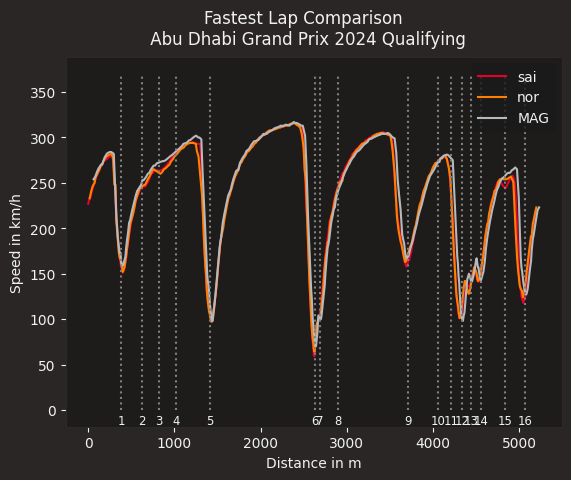

In [5]:
sai_lap = session.laps.pick_drivers(['SAI']).pick_fastest()
nor_lap = session.laps.pick_drivers(['NOR']).pick_fastest()
fast_lap = session.laps.pick_fastest()

##############################################################################
# Next we get the telemetry data for each lap. We also add a 'Distance' column
# to the telemetry dataframe as this makes it easier to compare the laps.

sai_tel = sai_lap.get_car_data().add_distance()
nor_tel = nor_lap.get_car_data().add_distance()
fast_tel = fast_lap.get_car_data().add_distance()

##############################################################################
# Finally, we create a plot and plot both speed traces.
# We color the individual lines with the drisai's team colors.

sai_color = fastf1.plotting.get_team_color(sai_lap['Team'], session=session)
nor_color = fastf1.plotting.get_team_color(nor_lap['Team'], session=session)
fast_color = fastf1.plotting.get_team_color(fast_lap['Team'], session=session)

fig, ax = plt.subplots()
ax.plot(sai_tel['Distance'], sai_tel['Speed'], color=sai_color, label='sai')
ax.plot(nor_tel['Distance'], nor_tel['Speed'], color=nor_color, label='nor')
ax.plot(fast_tel['Distance'], fast_tel['Speed'], color=fast_color, label=fast_lap["Driver"])


############################
# Corners
ax.vlines(x=circuit_info.corners['Distance'], ymin=0, ymax=370,
          linestyles='dotted', colors='grey')
for _, corner in circuit_info.corners.iterrows():
    txt = f"{corner['Number']}{corner['Letter']}"
    ax.text(corner['Distance'], -10, txt,
            va='center_baseline', ha='center', size='small')

ax.set_xlabel('Distance in m')
ax.set_ylabel('Speed in km/h')

ax.legend()
plt.suptitle(f"Fastest Lap Comparison \n "
             f"{session.event['EventName']} {session.event.year} Qualifying")

display(f"SAINZ: {sai_lap['LapTime'].seconds // 60}:{sai_lap['LapTime'].seconds % 60}:{sai_lap['LapTime'].microseconds}")
display(f"NORRIS: {nor_lap['LapTime'].seconds // 60}:{sai_lap['LapTime'].seconds % 60}:{sai_lap['LapTime'].microseconds}")
display(f"{fast_lap['Driver']}: {fast_lap['LapTime'].seconds // 60}:{fast_lap['LapTime'].seconds % 60}:{fast_lap['LapTime'].microseconds}")
plt.show()

In [7]:
session.laps.pick_drivers(['SAI'])

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
774,0 days 00:58:21.130000,SAI,55,0 days 00:01:32.999000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:38.437000,...,True,Ferrari,0 days 00:56:47.817000,2024-12-08 13:03:35.034,12,3.0,None,,False,False
775,0 days 01:00:10.900000,SAI,55,0 days 00:01:49.770000,2.0,1.0,NaT,NaT,0 days 00:00:18.329000,0 days 00:00:45.655000,...,True,Ferrari,0 days 00:58:21.130000,2024-12-08 13:05:08.347,126,2.0,None,,False,False
776,0 days 01:01:53.695000,SAI,55,0 days 00:01:42.795000,3.0,1.0,NaT,NaT,0 days 00:00:25.783000,0 days 00:00:44.623000,...,True,Ferrari,0 days 01:00:10.900000,2024-12-08 13:06:58.117,671,2.0,None,,False,False
777,0 days 01:03:22.690000,SAI,55,0 days 00:01:28.995000,4.0,1.0,NaT,NaT,0 days 00:00:18.166000,0 days 00:00:38.123000,...,True,Ferrari,0 days 01:01:53.695000,2024-12-08 13:08:40.912,1,2.0,None,,False,True
778,0 days 01:04:51.940000,SAI,55,0 days 00:01:29.250000,5.0,1.0,NaT,NaT,0 days 00:00:18.101000,0 days 00:00:38.189000,...,True,Ferrari,0 days 01:03:22.690000,2024-12-08 13:10:09.907,1,2.0,None,,False,True
779,0 days 01:06:21.193000,SAI,55,0 days 00:01:29.253000,6.0,1.0,NaT,NaT,0 days 00:00:18.165000,0 days 00:00:38.173000,...,True,Ferrari,0 days 01:04:51.940000,2024-12-08 13:11:39.157,1,2.0,None,,False,True
780,0 days 01:07:50.256000,SAI,55,0 days 00:01:29.063000,7.0,1.0,NaT,NaT,0 days 00:00:18.080000,0 days 00:00:38.207000,...,True,Ferrari,0 days 01:06:21.193000,2024-12-08 13:13:08.410,1,2.0,None,,False,True
781,0 days 01:09:19.458000,SAI,55,0 days 00:01:29.202000,8.0,1.0,NaT,NaT,0 days 00:00:18.142000,0 days 00:00:38.347000,...,True,Ferrari,0 days 01:07:50.256000,2024-12-08 13:14:37.473,1,2.0,None,,False,True
782,0 days 01:10:48.645000,SAI,55,0 days 00:01:29.187000,9.0,1.0,NaT,NaT,0 days 00:00:18.083000,0 days 00:00:38.353000,...,True,Ferrari,0 days 01:09:19.458000,2024-12-08 13:16:06.675,1,2.0,None,,False,True
783,0 days 01:12:17.965000,SAI,55,0 days 00:01:29.320000,10.0,1.0,NaT,NaT,0 days 00:00:18.038000,0 days 00:00:38.373000,...,True,Ferrari,0 days 01:10:48.645000,2024-12-08 13:17:35.862,1,2.0,None,,False,True


In [8]:
circuit_info

CircuitInfo(corners=              X             Y  Number Letter       Angle     Distance
0   4294.859375   2690.717773       1         -35.340600   386.308498
1   3848.351318   4987.570801       2          42.198164   621.431799
2   2206.551025   6155.120117       3        -163.169332   820.768056
3   2378.656250   8052.805176       4          -8.298533  1019.999858
4   1839.358276  11771.707031       5          84.326847  1415.257869
5  -2150.159424    655.311096       6        -148.988037  2628.050081
6  -1583.492065    587.163330       7          46.320930  2690.460618
7   -823.991882  -1256.985107       8        -144.588429  2896.221430
8   5774.805664  -4917.836914       9         -21.958205  3710.457624
9   3125.774414  -3602.140381      10          82.890762  4054.906096
10  1799.586548  -2781.958252      11          34.859890  4206.466579
11  1634.603882  -1529.775146      12         149.645096  4333.089783
12  2619.774414  -1222.781860      13         -41.811242  4446.524634
